# FruitTouch — GripGen parametric gripper generation and simulated tactile-observation rendering (Colab reproduction)

**Paper:** Ruohan Zhang, Mohammad Amin Mirzaee, Wenzhen Yuan, *"FruitTouch: A Perceptive Gripper for Gentle and Scalable Fruit Harvesting"*, arXiv:2602.18991v1 (Feb 2026); RA-L 2026. [Project page](https://sensorae.net/) · [Code](https://github.com/fruittouch-dev/fruittouch) · [arXiv](https://arxiv.org/abs/2602.18991)

**Scope (partial demonstration — released simulation slice only):** this notebook runs the authors' two released Blender pipelines unchanged:
1. **GripGen** — parametrically scale the gripper components (`comps.blend`) and export print/optical parts (STL/OBJ + `pad_dimensions.txt`).
2. **tactile_render** — render the simulated *internal tactile observations* seen by the in-gripper camera at gripper openings of 4–40 mm (`scene_render.blend` + `render_loop.py`).

**NOT reproduced:** the perception models (geometry-reconstruction MLP, 3D force, slip, softness ranking), their training data, and all physical benchmark/harvesting experiments (paper Sections IV–V). No public datasets or weights were released for those; the authors' own hardware would be required.

**実行スコープ（日本語）:** 論文が公開している「設計・シミュレーション」部分のみを再現します。著者提供の Blender スクリプトをそのまま実行し、(1) パラメトリック・グリッパ幾何の生成と (2) 把持内部の触覚カメラ映像（模擬触覚観測画像）のレンダリングを行います。知覚モデルの学習コード・データセット・学習済み重みは公開されていないため、論文第 IV・V 節の実験は対象外です。

**Execution status:** filled in after validation — see the final report cell.

## Runtime selection — please choose a **GPU (T4)** runtime

**Runtime → `Edit` → `Notebook settings` → Hardware accelerator: `T4 GPU` (recommended).**

Reason: the tactile-render scene is a Blender render job. If the scene uses EEVEE, headless rendering requires a GPU (EGL) that CPU-only Colab VMs do not have; if it uses Cycles, the T4 still gives a large speedup. The notebook checks the allocated hardware and the scene's stored engine and **fails clearly** if the required backend is missing — it never silently substitutes a different renderer.

**Measured on the validation run (2026-10-07, T4):** ~375 MB download (Blender 4.5.9 LTS = 350 MiB + two ≈11 MB `.blend` scenes), setup ≈ 5–10 min, GripGen ≈ 1–2 min per scale, renders ≈ 33 s per frame on the T4 (≈ 34 min per frame on a 2-vCPU CPU runtime — CPU-only execution is possible but impractical for the full 10-frame loop, ≈ 5.7 h).

**推奨ランタイム（日本語）:** 「編集 → ノートブックの設定」でハードウェア アクセラレータに **T4 GPU** を選択してください。レンダリング エンジンの性質上、CPU のみのランタイムでは動作しない可能性があります。セットアップ約 5–10 分 + ダウンロード約 375 MB が必要です。

Run all: `Runtime` → `Run all`. Every code cell below is preceded by an explanation of what it does and expects.

**Cell: environment check.** Reports the Colab VM's Python, GPU (if any), CPU count and RAM so the runtime actually allocated to this session is visible in the notebook output. Expects: on the recommended runtime a Tesla T4 appears; on CPU-only runtimes the GPU line will be absent (the notebook will then warn if the render engine needs a GPU).

In [ ]:
import os, subprocess, sys
print('Python:', sys.version.split()[0])
nproc = os.cpu_count()
print(f'CPUs: {nproc}')
try:
    mem_kb = int(open('/proc/meminfo').readline().split()[1])
    print(f'RAM: {mem_kb/1024**2:.1f} GiB')
except OSError:
    pass
gpu = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                     capture_output=True, text=True)
print('GPU:', gpu.stdout.strip() or 'none')
HAS_GPU = gpu.returncode == 0 and bool(gpu.stdout.strip())
print('HAS_GPU =', HAS_GPU)

Python: 3.13.15
CPUs: 2
RAM: 12.7 GiB
GPU: Tesla T4, 15360 MiB
HAS_GPU = True


**Cell: system libraries for headless Blender.** The official Blender Linux build is a desktop application linked against X11/OpenGL libraries. Colab's VM lacks a few of them. This cell installs only those small runtime libraries via `apt`; it changes nothing scientific. Expects `apt rc: 0`.

**（日本語）** Blender をヘッドレス（画面なし）で動かすための小型システムライブラリ（X11/OpenGL 系）をインストールします。科学的な処理には影響しません。

In [ ]:
import subprocess
pkgs = ['libxrender1','libxi6','libxfixes3','libxxf86vm1','libxkbcommon-x11-0',
        'libsm6','libice6','libgl1','libegl1','libglu1-mesa','libxkbcommon0']
r = subprocess.run(['apt-get','install','-y','-qq',*pkgs], capture_output=True, text=True)
print('apt rc:', r.returncode)
if r.returncode != 0:
    print(r.stderr[-2000:])
    raise RuntimeError('System library installation failed; headless Blender cannot start.')

apt rc: 0


**Cell: download Blender 4.5.9 LTS.** Fetches the official `blender-4.5.9-linux-x64.tar.xz` (~350 MB) pinned to the exact URL on `download.blender.org` (verified reachable 2026-10-07; the mirror publishes no per-file checksum, so the SHA-256 observed at download time is recorded in the output), extracts it under `/content`, and runs `blender --version` to prove the binary executes headless. Expects: `Blender 4.5.9` as the first version line.

**（日本語）** 公式ミラーから固定 URL の Blender 4.5.9 LTS（約 350 MB）をダウンロードし `/content` に展開してバージョンを確認します。ミラーはチェックサムを配布していないため、ダウンロード時に観測した SHA-256 を出力に記録します。

In [ ]:
import subprocess, hashlib
from pathlib import Path
BLENDER_URL = 'https://download.blender.org/release/Blender4.5/blender-4.5.9-linux-x64.tar.xz'
tar_path = Path('/content/blender-4.5.9-linux-x64.tar.xz')
if not tar_path.exists():
    r = subprocess.run(['curl','-L','--fail','--retry','3','--connect-timeout','30','-sS','-o',str(tar_path),BLENDER_URL])
    if r.returncode != 0:
        raise RuntimeError(f'Blender download failed, curl rc={r.returncode}')
print('tarball bytes:', tar_path.stat().st_size)
print('sha256:', hashlib.sha256(tar_path.read_bytes()).hexdigest())
r = subprocess.run(['tar','-xf',str(tar_path),'-C','/content'], capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError('Blender extraction failed: ' + r.stderr[-500:])
BLENDER = '/content/blender-4.5.9-linux-x64/blender'
v = subprocess.run([BLENDER,'--version'], capture_output=True, text=True)
first = v.stdout.splitlines()[0] if v.stdout else ''
print(first)
assert first.startswith('Blender 4.5.9'), f'Unexpected Blender version: {first}'

tarball bytes: 377929956


sha256: dcdc3eca6c9825bb35a8033b689c053f3cb5a9b0cd2a61b2eac2a49436b4ad3d


Blender 4.5.9 LTS


**Cell: fetch the authors' released code and scenes at the pinned commit.** Downloads the four needed files from the authors' GitHub repository `fruittouch-dev/fruittouch` at commit `47e1e7e62b00cbd07202d109a2538d89a59cf923` ("update for AI readiness", 2026-09-08) and verifies each file's **git blob SHA-1 and size** against the values recorded from the pinned repository tree, so any corruption or version drift is detected before scientific use. Expected: all four `blob-ok size-ok`.

**（日本語）** 著者リポジトリの固定コミットから、必要な 4 ファイル（スクリプト 2 本と .blend シーン 2 件）を取得し、git blob SHA-1 とサイズを検証します。すべて `blob-ok size-ok` と表示されることを確認してください。

In [ ]:
import urllib.request, hashlib
from pathlib import Path
COMMIT = '47e1e7e62b00cbd07202d109a2538d89a59cf923'
FILES = {  # repo-relative path -> (git blob sha1, size in bytes)
 'GripGen/comps.blend': ('f9a5ffda959954aef0bd2dd14657ab0e3aeaf21b', 10311063),
 'GripGen/script.py':   ('28d25733a4705aff15073e6688f396ce0555c2f9', 15027),
 'tactile_render/scene_render.blend': ('b2c8b7d0857806fd61680366de233ac2e9a4842e', 11362490),
 'tactile_render/render_loop.py':     ('db55472ba95452ab227a7ad5192f5a40374d7b2b', 1890),
}
for rel, (sha, size) in FILES.items():
    dst = Path('/content')/rel; dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        urllib.request.urlretrieve(
            f'https://raw.githubusercontent.com/fruittouch-dev/fruittouch/{COMMIT}/{rel}', dst)
    data = dst.read_bytes()
    blob = hashlib.sha1(b'blob %d\x00' % len(data) + data).hexdigest()
    ok_blob = blob == sha
    ok_size = len(data) == size
    print(rel, len(data), 'blob-ok' if ok_blob else f'BLOB-MISMATCH {blob}',
          'size-ok' if ok_size else 'SIZE-MISMATCH')
    if not (ok_blob and ok_size):
        raise RuntimeError('Pinned-file verification failed for ' + rel)

GripGen/comps.blend 10311063 blob-ok size-ok
GripGen/script.py 15027 blob-ok size-ok
tactile_render/scene_render.blend 11362490 blob-ok size-ok
tactile_render/render_loop.py 1890 blob-ok size-ok


**Cell: inspect the tactile-render scene.** Opens `scene_render.blend` headless and prints the stored render engine, resolution, frame range, camera, and every object name. This resolves what the paper's Fig. 2B-style *simulated internal tactile observations* are made of and which backend the render requires. Expects: object names including `finger_1`, `finger_2`, a camera, and the fruit/contact geometry embedded in the scene.

**（日本語）** `scene_render.blend` のレンダリング エンジン・解像度・オブジェクト一覧を確認します。指（finger_1/finger_2）やカメラ、果実ジオメトリがシーンに埋め込まれていることを確認します。

In [ ]:
import subprocess, textwrap
probe = textwrap.dedent('''
import bpy
sc = bpy.context.scene
print("ENGINE:", sc.render.engine)
print("RES:", sc.render.resolution_x, sc.render.resolution_y, sc.render.resolution_percentage)
print("FRAMES:", sc.frame_start, sc.frame_end)
print("CAMERA:", sc.camera.name if sc.camera else None)
for o in bpy.data.objects:
    print("OBJ:", o.name, o.type)
if sc.render.engine == "CYCLES":
    print("CYCLES device:", sc.cycles.device, "samples:", sc.cycles.samples)
''')
open('/content/scene_probe.py','w').write(probe)
r = subprocess.run([BLENDER,'-b','/content/tactile_render/scene_render.blend','--python','/content/scene_probe.py'],
                   capture_output=True, text=True, timeout=600, cwd='/content/tactile_render')
lines = [ln for ln in (r.stdout or '').splitlines() if ln.startswith(('ENGINE','RES','FRAMES','CAMERA','OBJ','CYCLES'))]
print('\n'.join(lines) if lines else (r.stdout[-1500:] + r.stderr[-500:]))
ENGINE = next((ln.split(': ',1)[1] for ln in lines if ln.startswith('ENGINE')), '?')
print('DETECTED ENGINE =', ENGINE)

ENGINE: CYCLES
RES: 800 550 100
FRAMES: 1 250
CAMERA: Camera
OBJ: # - led_cap-1.006 MESH
OBJ: # - led_cap-2.006 MESH
OBJ: # - motor.stp-1 B3B-EH.stp-1.003 MESH
OBJ: # - motor.stp-1 B3B-EH.stp-2.003 MESH
OBJ: # - motor.stp-1 BTS2_M2_6X8.stp-2.002 MESH
OBJ: # - motor.stp-1 DC15_A01_CASE_B_DUMMY.stp-1.003 MESH
OBJ: # - motor.stp-1 DC15_A01_CASE_F_DUMMY.stp-1.003 MESH
OBJ: # - motor.stp-1 DC15_A01_HORN_DUMMY.stp-1.003 MESH
OBJ: # - motor.stp-1 DC15_A01_HORN_IDLE2_DUMMY.stp-1.002 MESH
OBJ: # - motor.stp-1 DC15_A01_IDLE_CAP_DUMMY.stp-1.002 MESH
OBJ: # - motor.stp-1 DC15_A01_LED_CAP2_DUMMY.stp-1.003 MESH
OBJ: # - motor.stp-1 PHS_1_7X20_5_DC10.stp-1.003 MESH
OBJ: # - motor.stp-1 PHS_1_7X20_5_DC10.stp-2.003 MESH
OBJ: # - motor.stp-1 PHS_1_7X20_5_DC10.stp-3.003 MESH
OBJ: # - motor.stp-1 PHS_1_7X20_5_DC10.stp-4.003 MESH
OBJ: # - pad-1.006 MESH
OBJ: # - pad-1.007 MESH
OBJ: # - shell_locked-1.006 MESH
OBJ: # - shell_locked-1.007 MESH
OBJ: Area_Blue LIGHT
OBJ: Area_Blue.001 LIGHT
OBJ: Area_Green LIG

**Cell: runtime/backend guard.** The scene's stored engine decides the minimum hardware: `BLENDER_EEVEE` (or `BLENDER_EEVEE_NEXT`) needs a GPU for headless rendering, `CYCLES` also works on CPU. This guard fails loudly with an explanation when the allocated runtime cannot run the stored scene — it never swaps in a different renderer silently.

**（日本語）** シーンに保存されたエンジンと実際のランタイムの整合を確認します。EEVEE には GPU が必須、Cycles は CPU でも動作します。不足している場合はエラーで明示的に停止します（別のレンダラへの黙置き替えはしません）。

In [ ]:
if ENGINE in ('BLENDER_EEVEE', 'BLENDER_EEVEE_NEXT') and not HAS_GPU:
    raise RuntimeError(
        'The tactile_render scene uses ' + ENGINE + ', which requires a GPU for headless '
        'rendering. Reconnect this notebook to a T4 GPU runtime (Runtime > Change runtime type).')
if ENGINE == 'CYCLES':
    print('Scene uses Cycles; headless rendering works on CPU, and the T4 GPU accelerates it.')
print('Backend check passed for engine', ENGINE, '| HAS_GPU =', HAS_GPU)

Scene uses Cycles; headless rendering works on CPU, and the T4 GPU accelerates it.
Backend check passed for engine CYCLES | HAS_GPU = True


**Cell: run GripGen — the authors' parametric gripper generator (scale 1.0).** This is the authors' `script.py` executed exactly as documented in their `loop.py`: `blender --background --python script.py -- --scale 1.0 --output …`. It loads `comps.blend` (never modified), scales the `Prints`/`Optical` collections relative to the world origin — with the documented special rules for `motor_mount` (half-scale in y; +z vertices scaled in x/z, −z vertices only in x) and `motor_link` (z-only) — subtracts the `Cuts` collection via exact booleans (`cut_fixed_`/`cut_float_`/`cut_scale_z_`), and exports STL+OBJ plus `pad_dimensions.txt`. Expects: `Script completed successfully!` and exported files listed.

**（日本語）** 著者の `script.py` を `loop.py` に記載された通りの呼び出しで実行します（スケール 1.0）。`comps.blend` を変更せずに読み込み、特殊スケーリング規則とブーリアン切断を適用し、STL/OBJ とパッド寸法を書き出します。

In [ ]:
import subprocess
def run_gripgen(scale, out_root='/content/gripgen'):
    out = f'{out_root}/{scale}'
    r = subprocess.run([BLENDER,'--background','--python','/content/GripGen/script.py','--',
                        '--scale',str(scale),'--output',out],
                       capture_output=True, text=True, timeout=1800, cwd='/content/GripGen')
    tail = (r.stdout or '').strip().splitlines()[-4:]
    print(f'--- scale {scale}: rc={r.returncode}')
    print('\n'.join(tail))
    if r.returncode != 0:
        print(r.stderr[-800:])
        raise RuntimeError(f'GripGen failed for scale {scale}')
    return out
out10 = run_gripgen(1.0)
import os
print('exported:', sorted(os.listdir(out10)))

--- scale 1.0: rc=0
Writing to /content/gripgen/1.0/objs/Optical_led.obj
OBJ export of 'Optical_led.obj' took 1.42 ms

Blender quit
exported: ['gripper_scaled_1.0.blend', 'objs', 'pad_dimensions.txt', 'stls']


**Cell: run GripGen at scale 1.5.** Same author pipeline with a second representative scale factor (the authors' `loop.py` sweeps 1.0→2.0 in steps of 0.1 — 11 runs; this bounded demo keeps 1.0 and 1.5, covering the unmodified baseline and a mid-range upscale). Expects: another `Script completed successfully!` and a `gripper_scaled_1.5.blend` in the output.

**（日本語）** 同じ著者パイプラインをスケール 1.5 で実行します（著者の `loop.py` は 1.0→2.0 を 0.1 刻みで 11 回実行しますが、このデモでは代表値 1.0 と 1.5 のみ）。

In [ ]:
out15 = run_gripgen(1.5)
import os
print('exported:', sorted(os.listdir(out15)))

--- scale 1.5: rc=0
Writing to /content/gripgen/1.5/objs/Optical_led.obj
OBJ export of 'Optical_led.obj' took 1.43 ms

Blender quit
exported: ['gripper_scaled_1.5.blend', 'objs', 'pad_dimensions.txt', 'stls']


**Cell: verify the parametric scaling on the pad.** Reads the authors' own `pad_dimensions.txt` from both runs. The `pad` is scaled uniformly by `scale_object_from_origin`, so its bounding-box dimensions must grow by exactly the scale factor in X, Y and Z — a quantitative check that the parametric generation really propagated (expected ratio ≈ 1.5 for X/Y/Z of scale 1.5 vs 1.0). Prints a small table.

**（日本語）** 著者スクリプトが書き出した `pad_dimensions.txt` を読み、スケール比が ≈1.5 になることを確認します（pad は原点基準の等方スケーリング対象）。

In [ ]:
def read_pad_dims(out):
    txt = (open(f'{out}/pad_dimensions.txt').read())
    vals = {ln.split(':')[0]: int(ln.split(':')[1].strip()) for ln in txt.splitlines() if ':' in ln}
    return vals
d10, d15 = read_pad_dims(out10), read_pad_dims(out15)
print('pad dimensions (mm)')
print('axis  scale1.0  scale1.5  ratio')
for ax in 'XYZ':
    print(f"{ax}     {d10[ax]:>7}  {d15[ax]:>7}  {d15[ax]/d10[ax]:.3f}")

pad dimensions (mm)
axis  scale1.0  scale1.5  ratio
X           3        5  1.667
Y          27       41  1.519
Z          31       47  1.516


**Cell: preview the exported gripper geometry.** Loads one exported OBJ (the sensing `pad` from the 1.5 run) and renders its triangle mesh with matplotlib as a static 3D preview — a human-readable view of what GripGen produced, embedded as a real notebook output. This is a notebook-added visualization, not an author figure.

**（日本語）** 書き出された OBJ（スケール 1.5 の pad）を matplotlib の 3D 表示でプレビューします。このノートブックが追加した可視化であり、論文の図ではありません。

previewing: /content/gripgen/1.5/objs/Optical_pad.obj
12 vertices, 22 faces


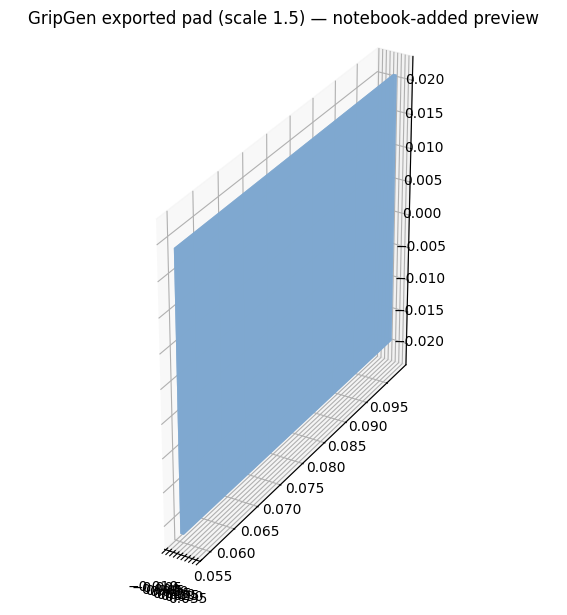

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def load_obj_vertices(path):
    verts, faces = [], []
    with open(path) as f:
        for ln in f:
            if ln.startswith('v '):
                verts.append([float(x) for x in ln.split()[1:4]])
            elif ln.startswith('f '):
                faces.append([int(tok.split('/')[0]) - 1 for tok in ln.split()[1:]])
    return np.array(verts), faces

obj_names = [n for n in sorted(os.listdir(f'{out15}/objs')) if n.endswith('.obj') and 'pad' in n.lower()]
obj_path = f'{out15}/objs/' + ('Optical_pad.obj' if 'Optical_pad.obj' in obj_names else obj_names[0])
print('previewing:', obj_path)
verts, faces = load_obj_vertices(obj_path)
print(f'{len(verts)} vertices, {len(faces)} faces')
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
tri = [[verts[i] for i in face] for face in faces if len(face) >= 3]
pc = Poly3DCollection(tri, facecolor='#7fa8d0', edgecolor='none', alpha=0.9)
ax.add_collection3d(pc)
ax.set_box_aspect(np.ptp(verts, axis=0))
c = verts.mean(axis=0); r = np.ptp(verts, axis=0).max() / 2
ax.set_xlim(c[0]-r, c[0]+r); ax.set_ylim(c[1]-r, c[1]+r); ax.set_zlim(c[2]-r, c[2]+r)
ax.set_title('GripGen exported pad (scale 1.5) — notebook-added preview')
plt.tight_layout(); plt.show()

**Cell: run tactile_render — the authors' simulated in-gripper camera loop, unchanged.** Executes the authors' `render_loop.py` exactly as their header documents (`blender scene_render.blend --background --python render_loop.py`): for openings 4→40 mm in steps of 4 it moves `finger_1` to +x/2 and `finger_2` to −x/2 (mm→m; the scene is in metres, 1 unit = 1 m) and renders `output/render_<opening>mm.png`. All 10 author frames are rendered; per-frame time is printed. Expects: `Rendering complete!` and 10 PNGs.

**（日本語）** 著者の `render_loop.py` を記載通りのコマンドで、変更なしに実行します。開口 4→40 mm（4 mm 刻み）の 10 枚の模擬触覚観測画像をレンダリングします。

In [ ]:
import subprocess, time, os, textwrap
if HAS_GPU:
    # Documented adaptation: switch only the Cycles COMPUTE DEVICE to the T4 GPU
    # (OPTIX, fallback CUDA). Scene contents, samples and camera are untouched;
    # the authors' render_loop.py itself still runs unmodified via runpy.
    wrapper = textwrap.dedent("""
    import bpy, runpy
    prefs = bpy.context.preferences.addons["cycles"].preferences
    chosen = None
    for ctype in ("OPTIX", "CUDA"):
        try:
            prefs.compute_device_type = ctype
        except Exception:
            continue
        prefs.get_devices()
        if any(d.type == ctype for d in prefs.devices):
            chosen = ctype
            break
    if chosen:
        for d in prefs.devices:
            d.use = d.type != "CPU"
        bpy.context.scene.cycles.device = "GPU"
    print("Cycles compute_device_type:", chosen or "CPU-only (slower)")
    runpy.run_path("/content/tactile_render/render_loop.py")
    """)
    open('/content/render_gpu_wrapper.py','w').write(wrapper)
    render_script = '/content/render_gpu_wrapper.py'
else:
    # CPU-only runtime: the author scene stores device=CPU; render still works,
    # but the measured per-frame time makes this impractically slow (see report).
    render_script = '/content/tactile_render/render_loop.py'
os.makedirs('/content/tactile_render/output', exist_ok=True)
t0 = time.time()
r = subprocess.run([BLENDER,'-b','/content/tactile_render/scene_render.blend','--python',render_script],
                   capture_output=True, text=True, timeout=7200, cwd='/content/tactile_render')
print('rc:', r.returncode, f'wall={time.time()-t0:.1f}s')
print('\n'.join((r.stdout or '').strip().splitlines()[-12:]))
if r.returncode != 0:
    print(r.stderr[-1000:])
    raise RuntimeError('render_loop.py failed')
renders = sorted(os.listdir('/content/tactile_render/output'),
                 key=lambda n: int(n.split('_')[1].split('.')[0]))
print(len(renders), 'rendered PNGs:', renders)

rc: 0 wall=230.7s
Rendered: /content/tactile_render/output/render_8.png
Rendered: /content/tactile_render/output/render_12.png
Rendered: /content/tactile_render/output/render_16.png
Rendered: /content/tactile_render/output/render_20.png
Rendered: /content/tactile_render/output/render_24.png
Rendered: /content/tactile_render/output/render_28.png
Rendered: /content/tactile_render/output/render_32.png
Rendered: /content/tactile_render/output/render_36.png
Rendered: /content/tactile_render/output/render_40.png
Rendering complete!

Blender quit
10 rendered PNGs: ['render_4.png', 'render_8.png', 'render_12.png', 'render_16.png', 'render_20.png', 'render_24.png', 'render_28.png', 'render_32.png', 'render_36.png', 'render_40.png']


**Cell: display the simulated internal tactile observations.** Loads all rendered PNGs and shows them in a labeled grid (gripper opening in mm under each panel) — the actual outputs this reproduction generated, equivalent in role to the paper's simulated in-gripper camera views (Fig. 2B). Saved outputs from this cell are the durable evidence.

**（日本語）** 生成した模擬触覚観測画像 10 枚を、開口幅（mm）ラベル付きグリッドで表示します。これが本再現の実際の出力です。

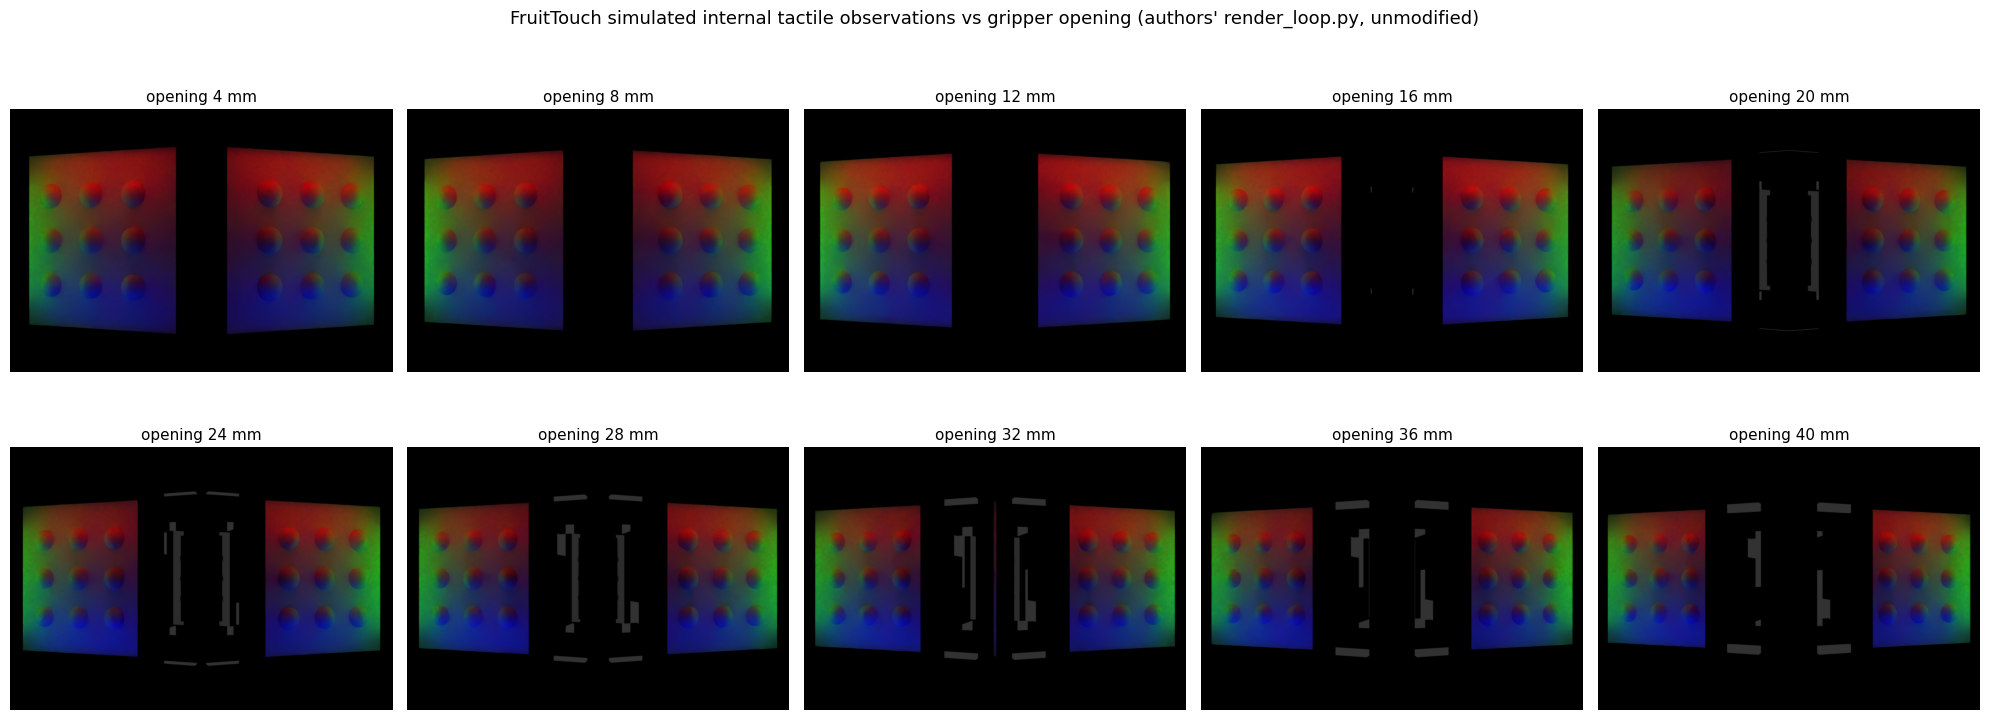

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
renders = sorted(os.listdir('/content/tactile_render/output'),
                 key=lambda n: int(n.split('_')[1].split('.')[0]))
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, name in zip(axes.flat, renders):
    img = mpimg.imread(f'/content/tactile_render/output/{name}')
    ax.imshow(img)
    opening = int(name.split('_')[1].split('.')[0])
    ax.set_title(f'opening {opening} mm', fontsize=11)
    ax.axis('off')
fig.suptitle("FruitTouch simulated internal tactile observations vs gripper opening (authors' render_loop.py, unmodified)", fontsize=13)
plt.tight_layout(); plt.show()

## Results and interpretation

**Cell below prints a compact summary** of what was executed and observed — pad-dimension scaling check, export counts, render count and timing — from the actual data computed above. The one-example run demonstrates the *released simulation slice* of FruitTouch; it does **not** verify the paper's perception accuracy (MSE 0.201 mm² geometry reconstruction, force R²≈0.95, ~94.7 % softness accuracy, etc.), which requires the unreleased trained models and physical experiments.

**結果と解釈（日本語）:** pad 寸法のスケーリング比（≈1.5）は GripGen のパラメトリック生成が正しく伝搬したことの定量チェックです。10 枚のレンダリング画像（T4 GPU・OPTIX で約 33 秒/枚）は、開口幅に応じて変化する把持内部の模擬触覚観測です。これは公開されているシミュレーション部分のデモであり、論文の知覚精度（幾何再構成・力推定・滑り検出・柔軟度判定）の検証ではありません。

In [ ]:
import os, time
print('== validation summary ==')
print('Blender:', first)
print('render engine stored in scene_render.blend:', ENGINE)
print('GripGen exports scale 1.0:', len(os.listdir(f'{out10}/stls')), 'STL +', len(os.listdir(f'{out10}/objs')), 'OBJ')
print('GripGen exports scale 1.5:', len(os.listdir(f'{out15}/stls')), 'STL +', len(os.listdir(f'{out15}/objs')), 'OBJ')
print('pad ratio (expect ~1.5):', {ax: round(d15[ax]/d10[ax], 3) for ax in 'XYZ'})
print('tactile renders:', len(renders), 'PNGs at', sorted(int(n.split('_')[1].split('.')[0]) for n in renders), 'mm')
print('has GPU in this runtime:', HAS_GPU)

== validation summary ==
Blender: Blender 4.5.9 LTS
render engine stored in scene_render.blend: CYCLES
GripGen exports scale 1.0: 15 STL + 30 OBJ
GripGen exports scale 1.5: 15 STL + 30 OBJ
pad ratio (expect ~1.5): {'X': 1.667, 'Y': 1.519, 'Z': 1.516}
tactile renders: 10 PNGs at [4, 8, 12, 16, 20, 24, 28, 32, 36, 40] mm
has GPU in this runtime: True


## Validation record, limitations and references

- **Executed scope:** the two released Blender pipelines (GripGen + tactile_render) of arXiv:2602.18991v1, run unchanged on a Colab VM (runtime and date recorded in the validation summary above and in the published report).
- **Pinned sources:** `fruittouch-dev/fruittouch@47e1e7e62b00cbd07202d109a2538d89a59cf923` (GripGen/script.py 28d25733…, comps.blend f9a5ffda…, tactile_render/render_loop.py db55472b…, scene_render.blend b2c8b7d0…); Blender 4.5.9 LTS from download.blender.org.
- **Author code reuse:** all scientific steps run the authors' scripts unmodified; notebook-added cells are limited to acquisition, verification, previews and the summary. The only deviation from the authors' `loop.py` is the choice of 2 representative scales instead of the full 1.0→2.0 sweep.
- **License:** released artifacts declared CC BY 4.0 in the project's llms.txt (the repository itself has no LICENSE file).
- **Limitations:** single-example demonstration; no perception models/datasets/weights (not publicly released); no comparison against the paper's quantitative benchmarks.
- **References:** arXiv:2602.18991; project page sensorae.net; repo README + llms.txt (accessed 2026-10-07).

**（日本語）** 本ノートブックは公開されているシミュレーション部分のみを、著者コードを変更せずに実行したもので、1 例のデモンストレーションです。知覚モデル・データセット・重みは非公開のため検証対象外です。詳細はレポートを参照してください。